In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("Agri_Data_Cleaned.csv")

target = "NDVI_Season_Mean"

df.head()

,FPAR,Avg_Salinity_Index,EVI,Rain_Temp_Ratio,Rainfall,Wind_Mean,Temp_Min,Wind_Max,Temp_Max,District,...,Heat_Stress_Days,Silt,Growth,CN_Ratio,Crop_Name,Organic_Carbon,Transplant,Season,NDVI_Season_Mean,LST_C
0,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Jan To March,8.73,Wheat,33.97,December,Rabi,0.511809,24.144525
1,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Jan To March,8.73,Maize 2,33.97,December,Rabi,0.511809,24.144525
2,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Dec To March,8.73,Boro,33.97,November,Rabi,0.511809,24.144525
3,0.631499,560.494023,0.311631,11.23,220.43,1.452917,8.35,4.33,30.58,Bagerhat,...,0,49.52,Dec To March,8.73,Sweet Potato,33.97,November,Rabi,0.511809,24.144525
4,0.416944,883.021928,0.308177,22.73,656.33,2.481885,16.01,5.86,41.26,Bagerhat,...,54,49.52,No Need To Do,8.73,Mango,33.97,April,Kharif 1,0.267147,28.431973


In [22]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 4608
Columns: 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4608 entries, 0 to 4607
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FPAR                   4608 non-null   float64
 1   Avg_Salinity_Index     4608 non-null   float64
 2   EVI                    4608 non-null   float64
 3   Rain_Temp_Ratio        4608 non-null   float64
 4   Rainfall               4608 non-null   float64
 5   Wind_Mean              4608 non-null   float64
 6   Temp_Min               4608 non-null   float64
 7   Wind_Max               4608 non-null   float64
 8   Temp_Max               4608 non-null   float64
 9   District               4608 non-null   object 
 10  Clay                   4608 non-null   float64
 11  LAI                    4608 non-null   float64
 12  Nitrogen               4608 non-null   float64
 13  Soil_Moisture_mm       4608 non-null   float64
 14  pH                     4608 non-n

In [23]:
df["NDVI_Season_Mean"].describe()

count    4608.000000
mean        0.373672
std         0.107128
min         0.000000
25%         0.305881
50%         0.389344
75%         0.441558
max         0.695371
Name: NDVI_Season_Mean, dtype: float64

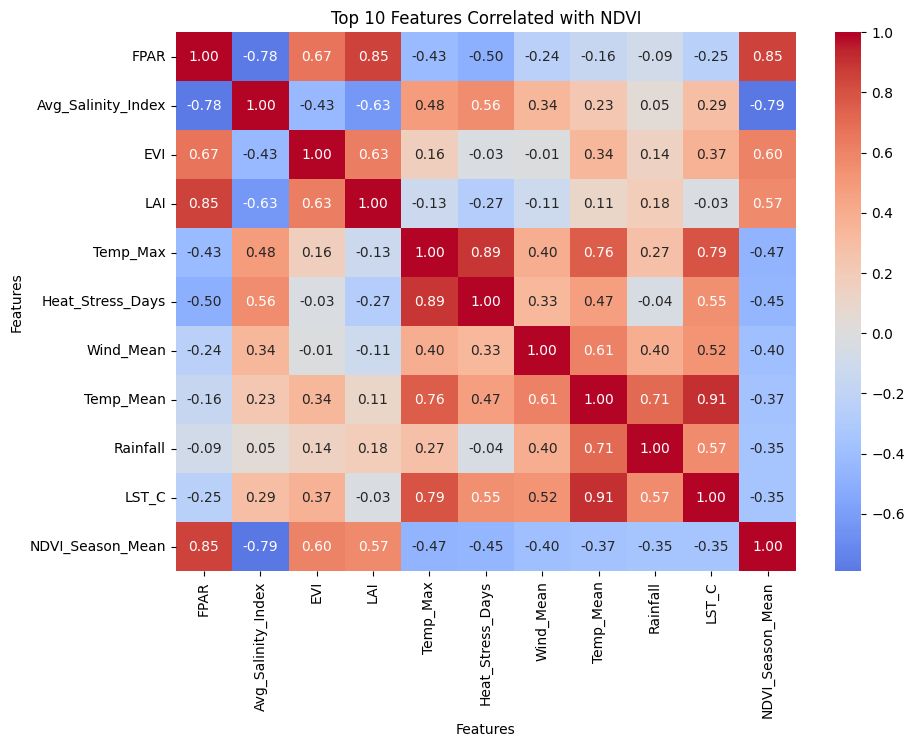

In [24]:
target = "NDVI_Season_Mean"

numeric_df = df.select_dtypes(include="number")

corr_with_target = numeric_df.corr()[target].drop(target)

top_features = (
    corr_with_target
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

cols = list(top_features) + [target]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Top 10 Features Correlated with NDVI")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_16736\862593842.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_ndvi.index, y=season_ndvi.values, palette="viridis")


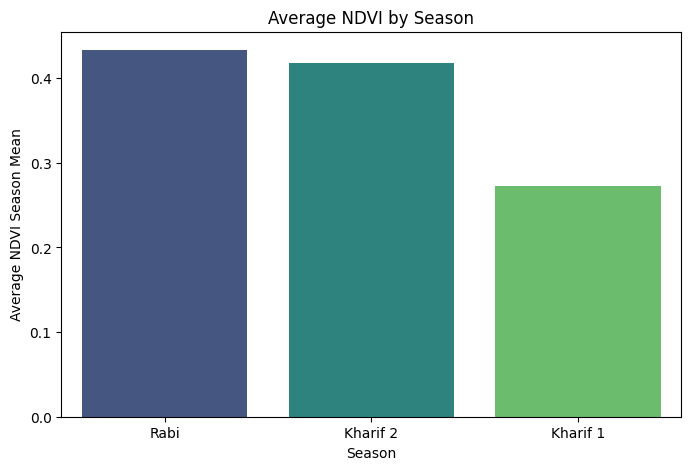

In [25]:
season_ndvi = df.groupby("Season")[target].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_ndvi.index, y=season_ndvi.values, palette="viridis")
plt.title("Average NDVI by Season")
plt.xlabel("Season")
plt.ylabel("Average NDVI Season Mean")
plt.show()

best_season = season_ndvi.idxmax()
worst_season = season_ndvi.idxmin()


C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_16736\2676958783.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_ndvi.reset_index(), x="mean_ndvi", y="Crop_Name", palette="mako")


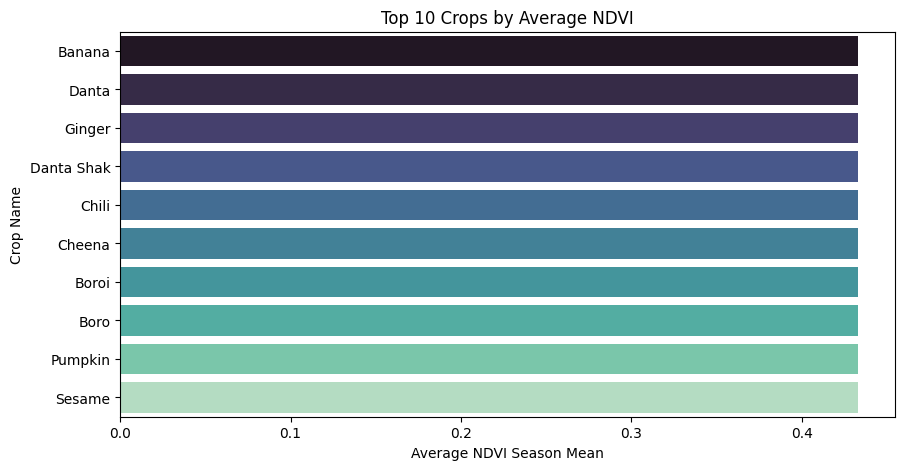

In [26]:
crop_ndvi = (
    df.groupby("Crop_Name")
    .agg(mean_ndvi=(target, "mean"), count=(target, "count"))
    .query("count >= 20")
    .sort_values("mean_ndvi", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=crop_ndvi.reset_index(), x="mean_ndvi", y="Crop_Name", palette="mako")
plt.title("Top 10 Crops by Average NDVI")
plt.xlabel("Average NDVI Season Mean")
plt.ylabel("Crop Name")
plt.show()


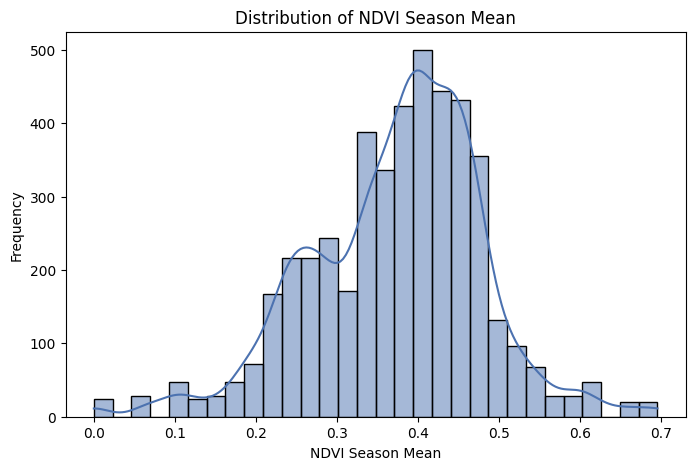

In [27]:
mean_ndvi = df[target].mean()
median_ndvi = df[target].median()

plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of NDVI Season Mean")
plt.xlabel("NDVI Season Mean")
plt.ylabel("Frequency")
plt.show()


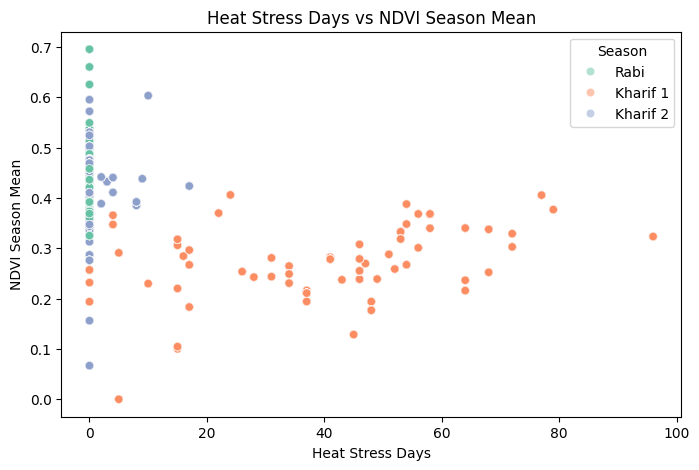

In [28]:
x_col = "Heat_Stress_Days"
corr_value = df[[x_col, target]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x_col, y=target, alpha=0.5, hue="Season", palette="Set2")
plt.title("Heat Stress Days vs NDVI Season Mean")
plt.xlabel("Heat Stress Days")
plt.ylabel("NDVI Season Mean")
plt.legend(title="Season")
plt.show()


In [29]:
x_col = "Avg_Salinity_Index"
corr_value = df[[x_col, target]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x_col, y=target, alpha=0.5, hue="Water_Availability_Cat", palette="coolwarm")
plt.title("Average Salinity Index vs NDVI Season Mean")
plt.xlabel("Average Salinity Index")
plt.ylabel("NDVI Season Mean")
plt.legend(title="Water Availability")
plt.show()


ValueError: Could not interpret value `Water_Availability_Cat` for `hue`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_24800\1350070822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Extreme_Heat_Risk", y=target, palette="Set3")


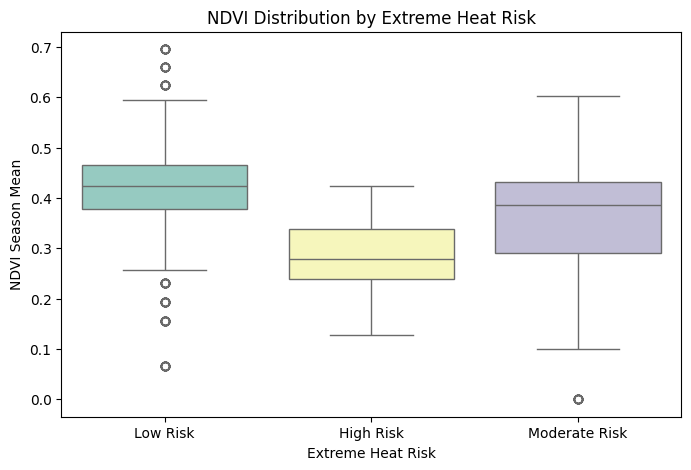

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Extreme_Heat_Risk", y=target, palette="Set3")
plt.title("NDVI Distribution by Extreme Heat Risk")
plt.xlabel("Extreme Heat Risk")
plt.ylabel("NDVI Season Mean")
plt.show()

risk_ndvi = df.groupby("Extreme_Heat_Risk")[target].median().sort_values(ascending=False)


In [ ]:
fig = px.scatter(
    df,
    x="Soil_Moisture_mm",
    y=target,
    color="Season",
    hover_data=["Crop Name", "District", "Rainfall", "Heat_Stress_Days"],
    title="Interactive Scatter Plot: Soil Moisture vs NDVI"
)

fig.update_layout(
    xaxis_title="Soil Moisture (mm)",
    yaxis_title="NDVI Season Mean",
    legend_title="Season"
)

fig.show()


ValueError: Value of 'hover_data_0' is not the name of a column in 'data_frame'. Expected one of ['FPAR', 'Avg_Salinity_Index', 'EVI', 'Rain_Temp_Ratio', 'Rainfall', 'Wind_Mean', 'Temp_Min', 'Wind_Max', 'Temp_Max', 'District', 'Clay', 'LAI', 'Nitrogen', 'Soil_Moisture_mm', 'pH', 'Dominant_Soil_Texture', 'AP_Ratio', 'Temp_Mean', 'Avg_Humidity', 'Heat_Stress_Days', 'Silt', 'Growth', 'CN_Ratio', 'Crop_Name', 'Organic_Carbon', 'Transplant', 'Season', 'NDVI_Season_Mean', 'LST_C'] but received: Crop Name